# PyTorch library for deep learning

PyTorch is a Python library designed to facilitate the development of deep learning applications. Its first public release dates back to January 18, 2017.
At the time, several competing deep learning libraries were available. Over the following years, however, the community largely consolidated around two major frameworks: PyTorch and TensorFlow. PyTorch has since gained increasing popularity, particularly in research and education, thanks to its flexibility and ease of use.

But PyTorch offers a few of things that make it particularly relevant for deep learning:
- PyTorch provides a core data structure, the *tensor*, which is a multidimensional array
that shares many similarities with NumPy arrays.
- both tensors and the operations on them can be used on the CPU or the GPU. Moving
computations from the CPU to the GPU in PyTorch requires  very limited effort. 
- PyTorch provides is the ability of tensors to keep track of the operations performed on them and to analytically
compute derivatives of an output of a computation with respect to any of its
inputs. This is used for numerical optimization, and it is provided natively by tensors thanks to PyTorch’s *autograd* engine

# Tensors

In the context of deep learning, tensors refer to the generalization of vectors and matrices to an arbitrary number of dimensions. Another name for the same
concept is *multidimensional array*. The dimensionality of a tensor coincides with the number of indexes used to refer to scalar values within the tensor

<div style="text-align: center;">
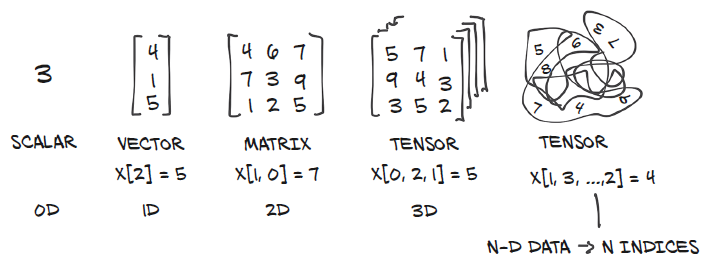
</div>

Python lists or tuples of numbers are collections of Python objects that are individually
allocated in memory. PyTorch tensors or NumPy arrays, on the other hand, are views over (typically) contiguous memory blocks containing
C numeric types rather than Python objects. Each element is a 32-bit (4-byte)
float in this case, as we can see on the right side of figure 3.3. This means storing a 1D
tensor of 1,000,000 float numbers will require exactly 4,000,000 contiguous bytes, plus
a small overhead for the metadata (such as dimensions and numeric type)

<div style="text-align: center;">
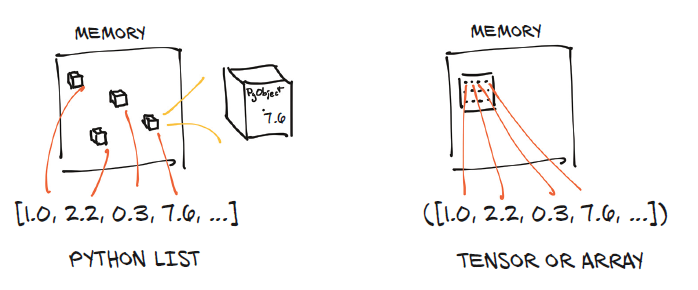
</div>



In [48]:
import torch  # import the torch module

a = torch.ones(3) # 1D tensor   
print(a)  # by default it creates floats
a[0] # each element is a 0D tensor

tensor([1., 1., 1.])


tensor(1.)

In [44]:
float(a[0]) # ... that can be transformed in a float

1.0

In [45]:
c = torch.ones(5, dtype=torch.int) # other types must by explicitly declared
c

tensor([1, 1, 1, 1, 1], dtype=torch.int32)

#### Indexing

In [46]:
b = torch.tensor([1,2,3,4,5])  
b[0:3] # from first to fourth EXCLUDED
b[:-1] # last excluded

tensor([1, 2, 3, 4])

In [47]:
points = torch.tensor([[4.0, 1.0], [5.0, 3.0], [2.0, 1.0]])  # we can directly construct a 2D tensor
points[:-1,:]  # indexing can be applied to each of the tensor’s dimensions

tensor([[4., 1.],
        [5., 3.]])

#### Adding dimensions with *unsqueeze*

In [28]:
b1 = b.unsqueeze(0) # a 1D tensor is transformed to a 2D tensor with 1 row
print(b1)
print(b1.shape)

tensor([[1, 2, 3, 4, 5]])
torch.Size([1, 5])


In [29]:
b2 = b.unsqueeze(1) # a 1D tensor is transformed to a 2D tensor with 1 column
print(b2)
b2.shape

tensor([[1],
        [2],
        [3],
        [4],
        [5]])


torch.Size([5, 1])

In [30]:
b1 = b.unsqueeze(0).unsqueeze(0)
b1.shape

torch.Size([1, 1, 5])

#### Transposition and permutation

In [31]:
b1_t = torch.transpose(b1, 0, 2)  # switches dimensions
print(b1_t)
b1_t.shape

tensor([[[1]],

        [[2]],

        [[3]],

        [[4]],

        [[5]]])


torch.Size([5, 1, 1])

In [37]:
x = torch.randn(2, 3, 4)
print(x.shape)
y = x.permute(2, 0, 1)
print(y.shape)

torch.Size([2, 3, 4])
torch.Size([4, 2, 3])


Importantly, *permute()* does not change the data itself; it changes how the dimensions are ordered/viewed

#### Moving tensors from CPU to GPU and back

In [36]:
points_gpu = torch.tensor([[4.0, 1.0], [5.0, 3.0], [2.0, 1.0]], device='cuda')  # direct contructor
points_gpu = points.to(device='cuda')  # alternative: migrate an existing array to gpu
points_gpu = points.cuda()  # alternative
print(points_gpu)

points_cpu = points_gpu.to(device='cpu') # back to cpu
points_cpu = points_gpu.cpu() # alternative
print(points_cpu)

tensor([[4., 1.],
        [5., 3.],
        [2., 1.]], device='cuda:0')
tensor([[4., 1.],
        [5., 3.],
        [2., 1.]])


#### Switching to NumPy and back

In [39]:
points = torch.ones(3, 4)
points_np = points.numpy()
print(points_np)
points = torch.from_numpy(points_np) # and back
print(points)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


The returned *numpy* array shares the same underlying buffer
with the tensor storage. This means the numpy method can be effectively executed at
basically no cost, as long as the data sits in CPU RAM. It also means modifying the
NumPy array will lead to a change in the originating tensor. If the tensor is allocated
on the GPU, PyTorch will make a copy of the content of the tensor into a NumPy array
allocated on the CPU.
While the default numeric type in PyTorch is 32-bit floating-point, for
NumPy it is 64-bit. As discussed in section 3.5.2, we usually want to use 32-bit
floating-points, so we need to make sure we have tensors of dtype torch
.float after converting